In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error

In [49]:
df = pd.read_csv("oral_cancer_prediction_dataset.csv")
df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_15268\2142148115.py:1: DtypeWarning: Columns (26,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("oral_cancer_prediction_dataset.csv")


,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,0.00,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,77772.50,177,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,101164.50,130,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,0.00,0,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,45354.75,52,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
# Remove unwanted columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df = df.drop(columns=["ID"], errors="ignore")

In [51]:
print(df.shape)

(84922, 24)


In [52]:
print(df.columns)

Index(['Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   84922 non-null  object 
 1   Age                                       84922 non-null  int64  
 2   Gender                                    84922 non-null  object 
 3   Tobacco Use                               84922 non-null  object 
 4   Alcohol Consumption                       84922 non-null  object 
 5   HPV Infection                             84922 non-null  object 
 6   Betel Quid Use                            84922 non-null  object 
 7   Chronic Sun Exposure                      84922 non-null  object 
 8   Poor Oral Hygiene                         84922 non-null  object 
 9   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 10  Family History of Cancer          

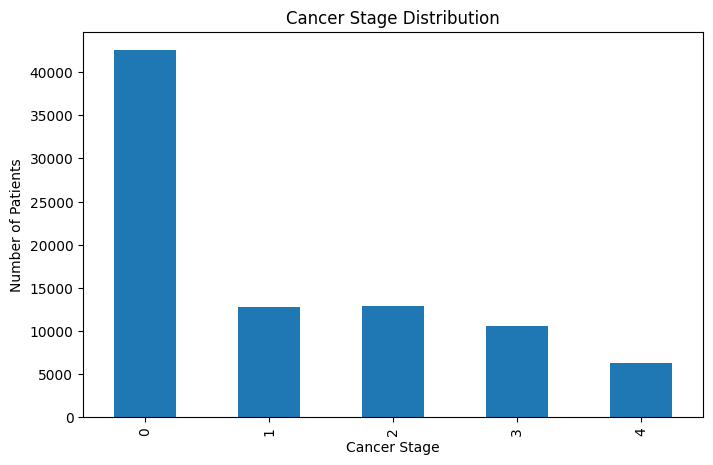

In [54]:
plt.figure(figsize=(8,5))
df["Cancer Stage"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Cancer Stage")
plt.ylabel("Number of Patients")
plt.title("Cancer Stage Distribution")
plt.show()

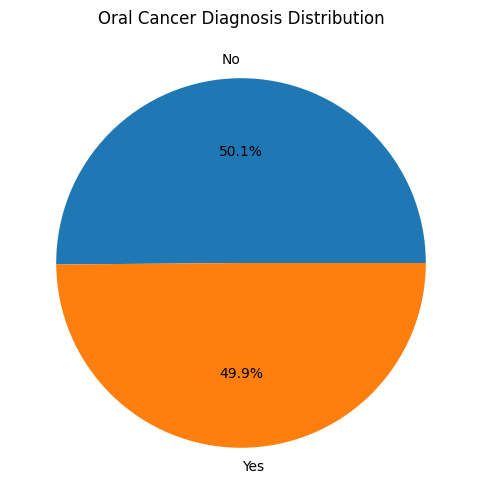

In [55]:
plt.figure(figsize=(6,6))
df["Oral Cancer (Diagnosis)"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Oral Cancer Diagnosis Distribution")
plt.ylabel("")
plt.show()

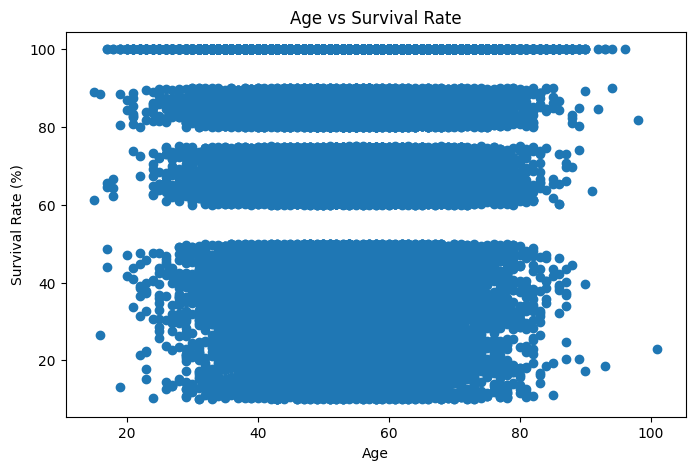

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Survival Rate (5-Year, %)"])
plt.xlabel("Age")
plt.ylabel("Survival Rate (%)")
plt.title("Age vs Survival Rate")
plt.show()

In [57]:
label_encoders = {}

categorical_columns = [
    "Gender",
    "Tobacco Use",
    "Alcohol Consumption",
    "HPV Infection",
    "Betel Quid Use",
    "Oral Cancer (Diagnosis)"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [58]:
features = [
    "Age",
    "Gender",
    "Tobacco Use",
    "Alcohol Consumption",
    "HPV Infection",
    "Betel Quid Use"
]

In [59]:
X1 = df[features]
y1 = df["Oral Cancer (Diagnosis)"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

diagnosis_model = RandomForestClassifier(random_state=42)
diagnosis_model.fit(X1_train, y1_train)

y1_pred = diagnosis_model.predict(X1_test)

print("Diagnosis Accuracy:",
      accuracy_score(y1_test, y1_pred))

Diagnosis Accuracy: 0.501913453046806


In [60]:
X2 = df[features]
y2 = df["Cancer Stage"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

stage_model = RandomForestClassifier(random_state=42)
stage_model.fit(X2_train, y2_train)

y2_pred = stage_model.predict(X2_test)

print("Stage Accuracy:",
      accuracy_score(y2_test, y2_pred))

Stage Accuracy: 0.4954371504268472


In [61]:
X3 = df[features]
y3 = df["Survival Rate (5-Year, %)"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

survival_model = RandomForestRegressor(random_state=42)
survival_model.fit(X3_train, y3_train)

y3_pred = survival_model.predict(X3_test)

print("Mean Absolute Error:",
      mean_absolute_error(y3_test, y3_pred))

Mean Absolute Error: 22.221753138731096


In [62]:
import os
os.makedirs("models", exist_ok=True)

In [63]:
joblib.dump(diagnosis_model, "models/diagnosis_model.pkl")
joblib.dump(stage_model, "models/stage_model.pkl")
joblib.dump(survival_model, "models/survival_model.pkl")

print("Models saved successfully!")

Models saved successfully!
